In [97]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.linalg import svd

from sklearn.datasets import load_svmlight_file
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

In [98]:
X, y = load_svmlight_file("./data/ijcnn1.bz2")
print(X.shape, y.shape)

(49990, 22) (49990,)


In [99]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=29990 / 49990,
    random_state=42,
)

X_train.shape, X_test.shape

((20000, 22), (29990, 22))

In [101]:
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

clf = LinearSVC(dual=False, random_state=42)

start_time = time.time()
clf.fit(X_train, y_train)
training_time_svc = time.time() - start_time
y_pred_svc = clf.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)

In [102]:
from sklearn.svm import SVC

clf_rbf = SVC(kernel="rbf", random_state=42)

start_time = time.time()
clf_rbf.fit(X_train, y_train)
training_time_rbf = time.time() - start_time
y_pred_rbf = clf_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

In [103]:
def compute_rkf(
    X_train: np.ndarray,
    X_test: np.ndarray,
    c: int = 300,
    gamma: float | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute Random Kitchen Features for RBF kernel approximation.

    Args:
        X_train (np.ndarray): Training data of shape (n1, p).
        X_test (np.ndarray): Test data of shape (n2, p).
        c (int): Number of random features to generate.
        gamma (float | None): Kernel coefficient for RBF kernel. If None, defaults to 1/p.

    Returns:
        tuple[np.ndarray, np.ndarray]: Transformed training and test data of shapes (n1, c) and (n2, c).

    """
    p = X_train.shape[1]

    if gamma is None:
        gamma = 1 / p

    W = rng.normal(0, np.sqrt(2 * gamma), size=(p, c))
    b = rng.uniform(0, 2 * np.pi, size=(1, c))

    def transform(X: np.ndarray) -> np.ndarray:
        """Transform the input data using Random Kitchen Features."""
        return np.sqrt(2 / c) * np.cos(np.dot(X, W) + b)

    return transform(X_train), transform(X_test)


In [104]:
Z_train, Z_test = compute_rkf(X_train.toarray(), X_test.toarray(), c=300)

clf_rkf = LinearSVC(dual=False, random_state=42)

start_time = time.time()
clf_rkf.fit(Z_train, y_train)
training_time_rkf = time.time() - start_time

y_pred_rkf = clf_rkf.predict(Z_test)
accuracy_rkf = accuracy_score(y_test, y_pred_rkf)

In [105]:
results = pd.DataFrame(
    {
        "Méthode": ["Linear SVM (Raw)", "Full RBF SVM", "RKF (c=300)"],
        "Accuracy": [accuracy_svc, accuracy_rbf, accuracy_rkf],
        "Temps (s)": [
            training_time_svc,
            training_time_rbf,
            training_time_rkf,
        ],
    },
)

results


,Méthode,Accuracy,Temps (s)
0,Linear SVM (Raw),0.922141,0.082011
1,Full RBF SVM,0.973791,1.132866
2,RKF (c=300),0.955152,0.713508


In [106]:
def compute_nystrom(
    X_train: np.ndarray,
    X_test: np.ndarray,
    c: int = 500,
    k: int = 300,
    gamma: float | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute Nystrom features for RBF kernel approximation.

    Args:
        X_train (np.ndarray): Training data of shape (n1, p).
        X_test (np.ndarray): Test data of shape (n2, p).
        c (int): Number of landmark points to use.
        k (int): Number of singular vectors to retain.
        gamma (float | None): Kernel coefficient for RBF kernel. If None, defaults to 1/p.

    Returns:
        tuple[np.ndarray, np.ndarray]: Transformed training and test data of shapes (n1, k) and (n2, k).

    """
    n1, p = X_train.shape
    if gamma is None:
        gamma = 1 / p

    indices = rng.choice(n1, size=c, replace=True)
    X_subset = X_train[indices]

    W = rbf_kernel(X_subset, X_subset, gamma=gamma)
    V, Sigma, _ = svd(W)

    Vk = V[:, :k]
    Sigmak = Sigma[:k]

    Mk = Vk @ np.diag(1.0 / np.sqrt(Sigmak))

    C_train = rbf_kernel(X_train, X_subset, gamma=gamma)
    C_test = rbf_kernel(X_test, X_subset, gamma=gamma)

    Z_train = C_train @ Mk
    Z_test = C_test @ Mk

    return Z_train, Z_test


In [107]:
c_values = np.arange(20, 650, 50)
results_list = []

gamma_fixed = 1 / X_train.shape[1]

for c in c_values:
    start = time.time()
    Z_tr_rkf, Z_te_rkf = compute_rkf(X_train.toarray(), X_test.toarray(), c=c, gamma=gamma_fixed)
    clf = LinearSVC(dual=False, random_state=42).fit(Z_tr_rkf, y_train)
    results_list.append(
        {
            "c": c,
            "Méthode": "RKF",
            "Accuracy": clf.score(Z_te_rkf, y_test),
            "Temps (s)": time.time() - start,
        },
    )

    if c > 10: # noqa: PLR2004
        start = time.time()
        Z_tr_nys, Z_te_nys = compute_nystrom(
            X_train, X_test, c=c, k=c - 10, gamma=gamma_fixed,
        )
        clf = LinearSVC(dual=False, random_state=42).fit(Z_tr_nys, y_train)
        results_list.append(
            {
                "c": c,
                "Méthode": "Nyström",
                "Accuracy": clf.score(Z_te_nys, y_test),
                "Temps (s)": time.time() - start,
            },
        )

df_res = pd.DataFrame(results_list)


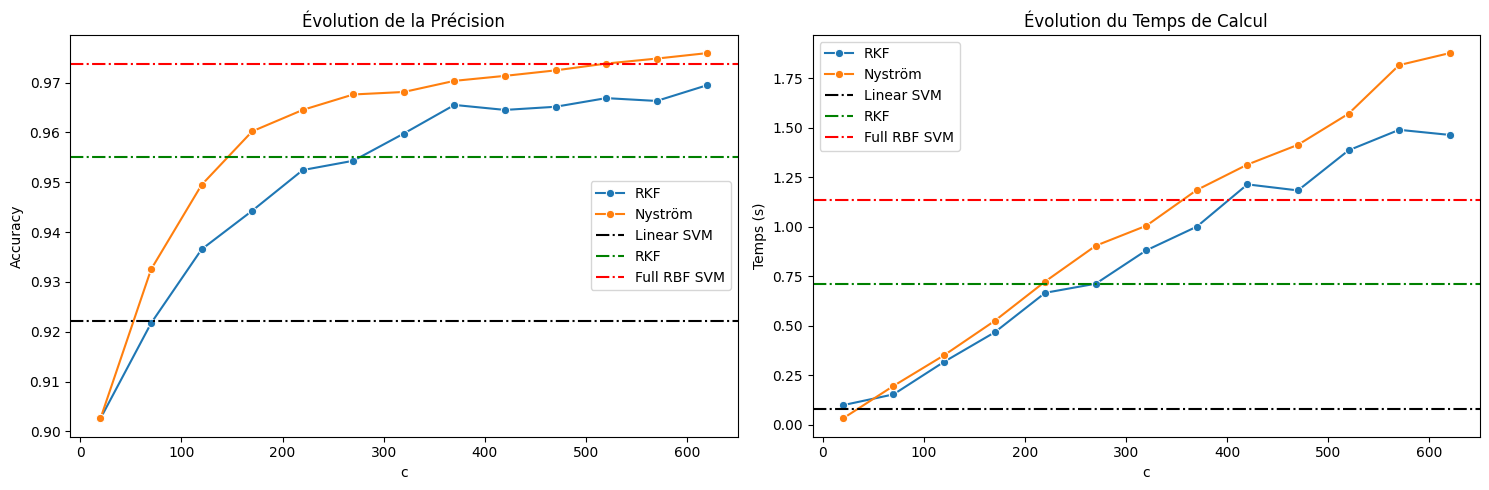

In [114]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy curves
sns.lineplot(data=df_res, x="c", y="Accuracy", hue="Méthode", marker="o", ax=ax[0])
ax[0].set_title("Évolution de la Précision")
ax[0].axhline(y=accuracy_svc, color="k", linestyle="-.", label="Linear SVM")
ax[0].axhline(y=accuracy_rkf, color="g", linestyle="-.", label="RKF")
ax[0].axhline(y=accuracy_rbf, color="r", linestyle="-.", label="Full RBF SVM")

handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles=handles, labels=labels)

# Time curves
sns.lineplot(data=df_res, x="c", y="Temps (s)", hue="Méthode", marker="o", ax=ax[1])
ax[1].set_title("Évolution du Temps de Calcul")

ax[1].axhline(y=training_time_svc, color="k", linestyle="-.", label="Linear SVM")
ax[1].axhline(y=training_time_rkf, color="g", linestyle="-.", label="RKF")
ax[1].axhline(y=training_time_rbf, color="r", linestyle="-.", label="Full RBF SVM")

handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles=handles, labels=labels)

plt.tight_layout()
plt.show()